# Morphological operations/ Les operations morphologique

### importer les packages 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

### chargement d'image 

les dimension de l'image :  (576, 768)
l'hauteur de l'image :  576
largeur de l'image : 576


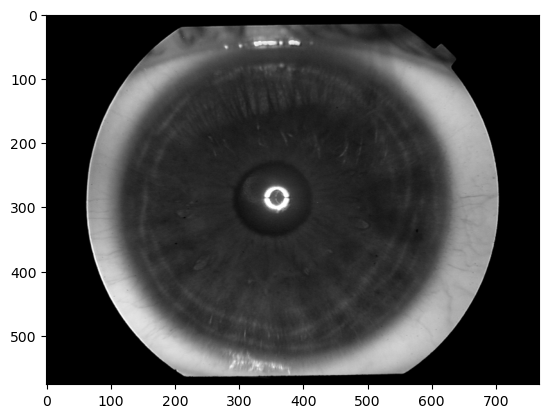

In [2]:
img = cv.imread('001L_1.png',0)
## dimension de l'image
m,n = img.shape
print("les dimension de l'image : ", img.shape)
## largeur et hauteur de l'image
print("l'hauteur de l'image : ",m)
print("largeur de l'image :",m)
## afichage de l'image
plt.imshow(img, cmap=plt.get_cmap('gray'))

## Binary Transformation / Transformation Binaire :

In [3]:
def binaire(img):
    thresholdValue = np.mean(img)
    m, n = img.shape
    # transformer l'image en noir et blanc # tansform image to Black and white
    for i in range(m):
        for j in range(n):
            if (img[i][j] > thresholdValue):
                img[i][j] = 255
            else:
                img[i][j] =0
    return img

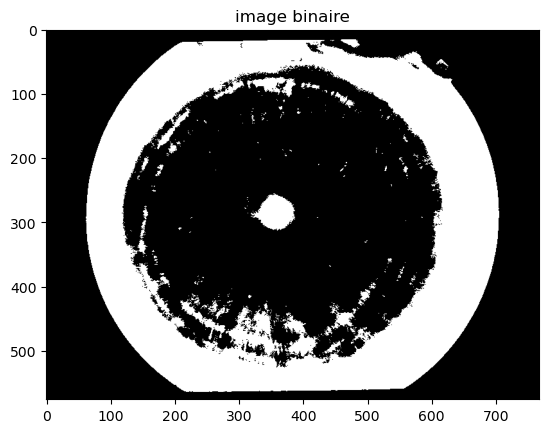

True

In [4]:
bw = binaire(img)
plt.imshow(bw, cmap=plt.get_cmap('gray'))
plt.title('image binaire')
plt.show() 
cv.imwrite('binaire.png',bw)

## L'Érosion

it is a process used to separate connected objects. This operation removes protrusions or rough edges.

**Definition** :
Let X be a set and B a structuring element. 
The erosion of X by B is given by:

$$ ϵB(X) = X ⊖ B = { x ∈ image | B_x ⊂ X }$$

Which means: the set of points x in the image such that B is completely 
contained in X when B is centered at x.


Il s’agit d’un processus qui permet de séparer des objets qui sont collés. cette opération permet de supprimer des extrusions (ou aspérités).


**Définition :**
Soit X un ensemble et B un élément structurant, l’érosion de X par B est donnée par :

$$ ϵB(X)=X⊖B={x∈image|Bx⊂X}$$

C'est-à-dire l’ensemble des points x de l'image, tels que B est totalement inclus dans X si B est centré en x.

Partons d’un objet blanc sur fond noir et observons l’application de l’érosion sur cet exemple.

Ne perdons pas de vue que l’application de l’érosion sur un tel exemple avec l’élément structurant va réduire la taille de l’objet.

In [5]:
element_1 = np.ones((1,1),np.uint8)

In [6]:
# first parameter is the image 
#  kernel is the matrix with which image is convolved 
#third parameter is the number of iterations, which will determine how much you want to erode/dilate a given image.
def erosion(img,kernel,iteration):
    m,n= img.shape 
    K = (iteration-1)//2
    Ero= np.zeros([m,n])
    temp=[]
    for i in range(K, m-K):
        for j in range(K,n-K):
            temp= img[i-K:i+K+1, j-K:j+K+1]*kernel
            Ero[i,j]= np.min(temp)
    return Ero

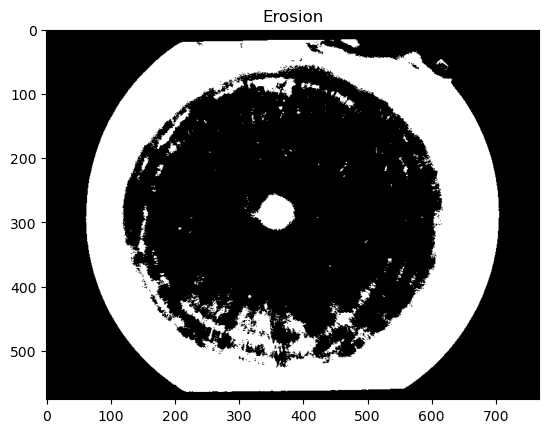

In [7]:
img_ero = erosion(bw,element_1,iteration=1)
plt.imshow(img_ero,cmap='gray')
plt.title("Erosion ")
plt.title("Erosion")
plt.show()

### verifying the result with OpenCV / Vérification de resultat avec opencv

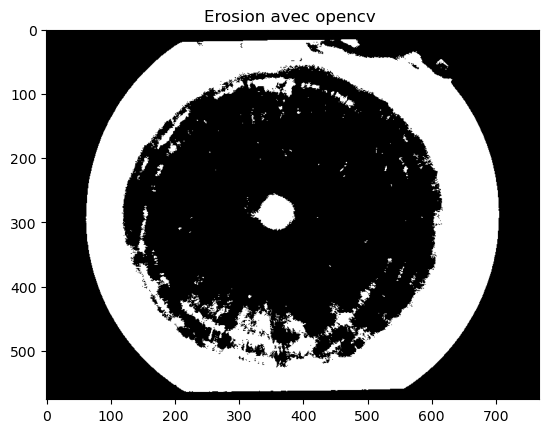

In [8]:
cv2_erosion = cv.erode(bw, element_1, iterations=1)
plt.figure()
plt.imshow(cv2_erosion,cmap='gray')
plt.title("Erosion avec opencv ")
plt.show()

## Dilation:
This is a process that repairs broken lines. This operation also fills gaps (or holes) in an object. Definition: Let X be a set and B a structuring element. The dilation of X by B is given by:
   $$ δB(X)=X⊕B={x∈image|Bx∩X≠∅}  $$
That is, the set of points x in the image such that Bx has a non-empty intersection with X.

Note: In other words, the dilation of X corresponds to the erosion of the complement of X.

## La Dilatation :
Il s'agit d'un processus qui permet de réparer des traits interrompus :
Cette opération permet aussi de combler les intrusions (ou trous) dans un objet :
Définition :
Soit X un ensemble et B un élément structurant, la dilatation de X par B est donnée par :

  $$ δB(X)=X⊕B={x∈image|Bx∩X≠∅}  $$

 C'est-à-dire l'ensemble des points x de l'image, tels que Bx a une intersection non vide avec X.

Remarque : autrement dit, la dilatation de X correspond donc à l'érosion du complémentaire de X.

In [9]:
element_2 = np.array([[1,1,1],
                    [1,1,1],
                    [1,1,1]])
def Delatation(img,element,iteration):
    m,n = img.shape
    Dilate= np.zeros([m,n])
    temp = []
    for i in range(iteration, m - iteration):
        for j in range(iteration,n - iteration):
            temp = img[ i - iteration:i + iteration+1, j-iteration: j + iteration + 1 ]*element
            Dilate[i,j] = np.max(temp)           
    return Dilate

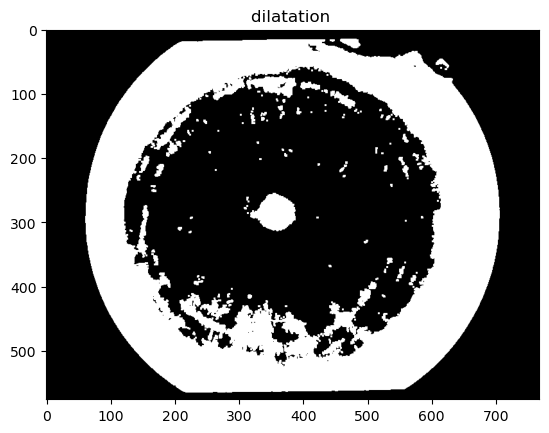

In [10]:
img_dela= Delatation(cv2_erosion,element_2, 1)
plt.imshow(img_dela,cmap=plt.get_cmap('gray'))
plt.title("dilatation ")
plt.show()

### vérification de resultat avec opencv

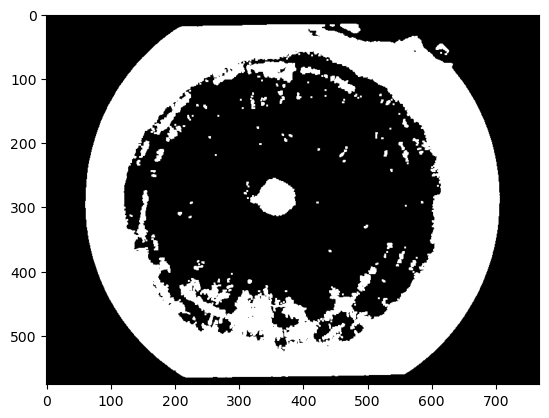

In [11]:
img_dilation = cv.dilate(cv2_erosion, element_2, iterations=1)
plt.imshow(img_dilation, cmap=plt.get_cmap('gray'))

In [12]:
#### enregister l'images :
cv.imwrite('delation.png',img_dela)
cv.imwrite('erosion.png',img_ero)

True